<center>
<h1>ISAT 341: Data Science and Machine Learning</h1>
    </center>
    
<center>
    <h1 style='color:blue'>Activity 8: Model Evaluation and Confusion Matrices</h1>
    </center>
    
<center>
    <h2>(classifier: Support Vector Machines)</h2>
    </center>
    
<img src="images/confusion_matrix.png" width=400; height=400>

### By Joshua Brewington

<h2><u>Ojbectives</h2>
    
- Create a professional looking Jupyter Notebook
- Download the Iris flower dataset frorm the UCI Machine Learning Repository
- Use Pandas and Pandas Dataframes to Import and Save Data
- Data Preprocessing: Use subset of Iris flower dataset for binary classification
- Use Numpy to encode the catergorical class labels into integer class labels
- Perform Decision Boundary Plotting with MatPlotLib
- Use Support Vector Classifier on Iris Flower Subset
- Create Model Evaluation with Classification Report Confusion Matrix
- Use Scitkit-Learn built-in Label Encoder

## Load the iris flower Dataset

Load the iris flower dataset from the UCI Machine Learning Repository into a Pandas Dataframe.

In [1]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                'machine-learning-databases/iris/iris.data', header=None)
df.tail()
# Here we are loading the dataset from UCI Machine Learning repository

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


## Loading (and saving) the Iris flower Dataset

There are times when you need to save all of part of a dataset to your storage device. The code snippet below indicates how to save a pandas dataframe (that was populated with the iris flower dataset from the UCI Machine Learning Repository) to a CSV file.

### Load the iris flower datset from the UCI Machine Learning Repository into a Pandas Dataframe

In [2]:
# Load CSV using Pandas from URL

import pandas
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
names = ['sepal_length','sepal_width','petal_length','petal_width','class']
iris_df = pandas.read_csv(url, names=names)
# print shape and last five rows
print(iris_df.shape)
iris_df.tail()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Save the iris flower dataset to a CSV file

In [3]:
# save the dataset downloaded from the web
iris_df.to_csv('iris_flower_dataset.csv', index=False)

### Reload the saved from the CSV file

In [4]:
# reload the saved dataset from the web
iris_df_from_file = pd.read_csv('iris_flower_dataset.csv')
iris_df_from_file.tail()

,sepal_length,sepal_width,petal_length,petal_width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Next, extract the first 100 class labels (this corresponds to 50 Iris-Setosa and 50 Iris_Veriscolor flowers, respectively)

Using matplotlib, we are extracting the first 100 columns for the first row.

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# select setosa and versicolor
y = df.iloc[0:100,4].values

### Class Label Encoding

Now, let's encode the class labels as integers to use with our Perceptron model we will develop in the lab. This means we will convert them as follows: 1b = Veriscolor and -1 = Setosa. We will use Numpy to do this as follows:

Here we are encoding the class labels into integers.

In [6]:
y = np.where(y == 'Iris-setosa', -1, 1)
# this is the y vector for Iris-setosa

To keep the analyis simple, we will only use two features from the reduced dataset. Let's extract the first feature column (sepal length) and the third feature column (petal length) to use in our analysis.

We are simplifying the features to make the process easier.

In [7]:
# extract sepal length and petal length
X = df.iloc[0:100,[0,2]].values

We now have extracted the subset of data from the Iris flower dataset and can proceed with plotting it. We examine the data to see if it is linearly separable with a well-defined decision boundary. Before we proceed make sure you understand what is occuring with the new NumPy and Pandas commands:

    1. The numpy np.where command
    2. The Pandas df.iloc command
    3. The numpy np.zeros command (see below)

### Decision Boundary Plotting

We can better visualize the data by a simply plot. Note the use of python lists in the code below and make sure you know what is occuring.

Below we are displaying the first 50 versicolors and 50 setosa to get a decison boundary plot.

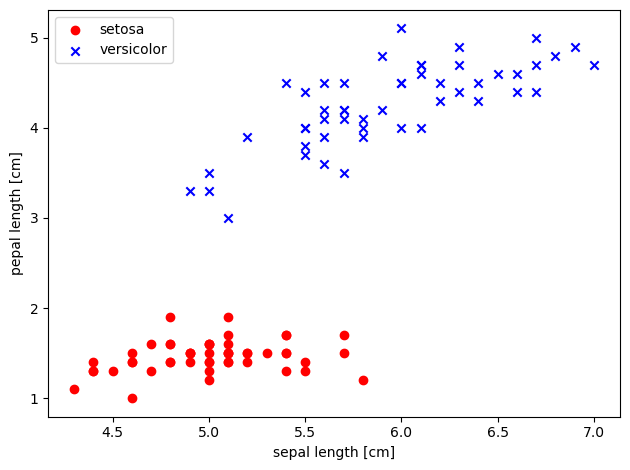

In [8]:
# plot data
plt.scatter(X[:50,0], X[:50,1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100,0], X[50:100,1],
            color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('pepal length [cm]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('iris_decision_boundary.png', dpi=300)
plt.show()

### Test/Train Splits of Data

Use the Scitkit learn train_test_split function (defualt to a 75%/25? train/test split) to split the above data into traning/testing sets. Let's agree to set: random_state=0

In [9]:
from sklearn.model_selection import train_test_split

#test_size=.20 means the test consists of 20% of the data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25,random_state=0)

### Support Vector Classifier

Up to this point, we have used the K-NN and Logistic Regression algorithms for our classifiers. Another, popular (and powerful) alogrithm is the Support Vector Machine (see my slides for a simple introduction). Create a model using the support vector classifier as follows:


### Fitting the Model using a Linear Support Vector Machine Classifier

In [10]:
from sklearn.svm import LinearSVC
# instantiate the model and fit the data
lsvc=LinearSVC()
lsvc.fit(X_train, y_train)

LinearSVC()

### Let's Evaluate the Support Vector Machine Model

We do this by using the test set that we created earlier. Note that this data was not used to build (train) the model, but we do know what the species is (correct class labels) for each flower in the test set. Thus, we can make prediction for each iris flower in the test data and compare it to its knwn class label (known species). We can measure how well the model works by computing the model's accuracy which is the fraction of flowers for which the right species was predicted:

In [11]:
y_pred = lsvc.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))
# This is predicting using 'lsvc.predict()'

Test set predictions:
 [-1  1 -1  1  1  1 -1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1
 -1]


These lines of code use the X_test to predict the depedent variables using a support vector machine.

In [12]:
print("Test set score: {0:0.2f}".format(np.mean(y_pred==y_test)))
# Test for the test set score

Test set score: 1.00


We can also use the score method of the lsvc object, which will compute the test set score accuracy for us:

In [13]:
print("Test set score: {0:0.2f}".format(lsvc.score(X_test,y_test)))
# Test for the test set score

Test set score: 1.00


### Model Performance Evaluation via the Classification Report and the Confusion Matrix

Determine how well the model you built works by applying model evaluation metrics (i.e. print the classification report and the confusion matrix.) Note. You will have to import as follows to use the metrics from sklearn import metrics

### Confusion Matrix

In [14]:
from sklearn import metrics
# import metrics
print("Confusion Matrix:")
print(metrics.confusion_matrix(y_test,y_pred))

Confusion Matrix:
[[13  0]
 [ 0 12]]


### Confusion Matrix (using ConfusionMatrixDisplay)

Scikit-Learn has a nicer looking confusion matrix which you should use from this point forward. (Also, recall the we set 1 = Versicolor and -1 = Setosa.)

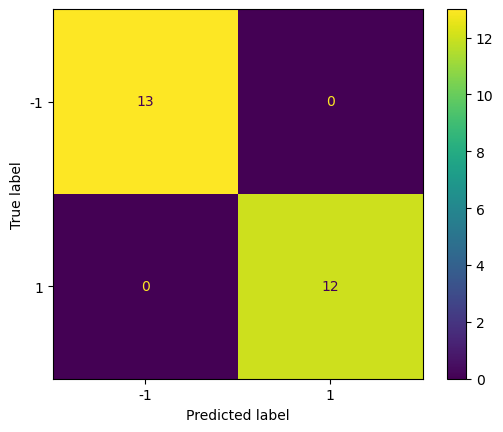

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred, labels=lsvc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lsvc.classes_)
disp.plot()
plt.show()
# Display a confusion matrix

# Comments and Questions

In [16]:
# Load the iris flower dataset from a text file
import pandas as pd
df = pd.read_csv('data\dataset_iris.txt', encoding='utf-8',comment='#',sep=',')
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Question 1:

In [17]:
X = df.iloc[:,:4].values
y = df['class'].values
np.unique(y)

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

These lines of code select the specifc size of the dataset and puts them into a Numpy array.

In [18]:
from sklearn.preprocessing import LabelEncoder
# instantiate label encoder
l_encoder = LabelEncoder()
# encode the labels
l_encoder.fit(y)
#display
l_encoder.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

### Question 2:

The output is encoding the classes as integers.

### Question 3:

In [19]:
y_enc = l_encoder.transform(y)
np.unique(y_enc)

array([0, 1, 2])

This output displays the numerical values that are assigned to the classes.

### Question 4:

In [20]:
print(y_enc)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


This line prints the total array of encoded labels from the line above.

### Question 5:

In [21]:
np.unique(l_encoder.inverse_transform(y_enc))

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

The l_encoder.inverse_transform(y_enc) transforms the encoded array back to being the class names.

### Comment:

We extracted the iris flower dataset from a URL and saved it, then loaded it into a CSV file. From here, we took the first 100 class labels and put them into versicolor setosa respectively. We then encoded the class labels using Numpy into integers with 1 = Versicolor and -1 = Setosa. These encoded labels were then plotted to visualize the data. With our decision boundary now plotted, we can see that there is a clear 'decision boundary' in the space between the versicolor and setosa. Therefore, we were successful in preprocessing the data, encoding it, and creating a decision boundary.